数据加载完成:
  训练集: 1295样本, 63特征
  测试集: 324样本, 63特征

开始训练BP神经网络...
Epoch 100/1000, Loss: 1.4887, Accuracy: 0.7097
Epoch 200/1000, Loss: 0.7612, Accuracy: 0.8958
Epoch 300/1000, Loss: 0.4581, Accuracy: 0.9382
Epoch 400/1000, Loss: 0.3201, Accuracy: 0.9544
Epoch 500/1000, Loss: 0.2487, Accuracy: 0.9668
Epoch 600/1000, Loss: 0.2056, Accuracy: 0.9730
Epoch 700/1000, Loss: 0.1770, Accuracy: 0.9784
Epoch 800/1000, Loss: 0.1566, Accuracy: 0.9815
Epoch 900/1000, Loss: 0.1411, Accuracy: 0.9830
Epoch 1000/1000, Loss: 0.1288, Accuracy: 0.9846

训练完成！总耗时: 2.73秒


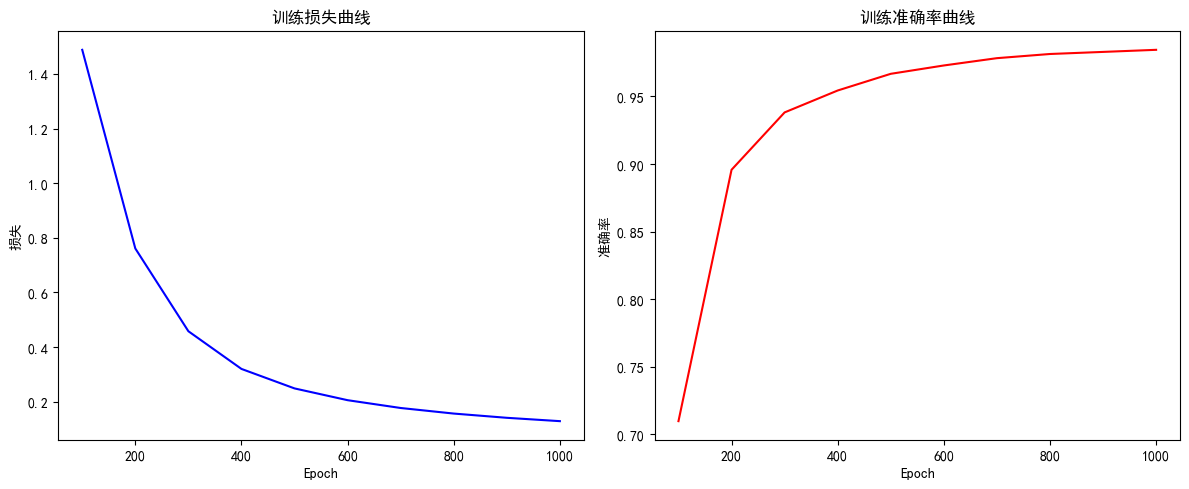

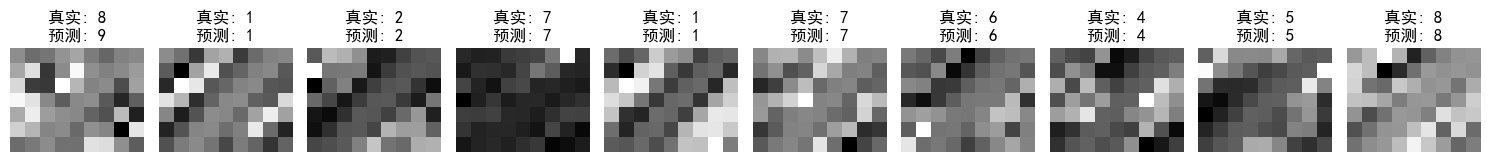


=== 训练参数 ===
       参数        值
0  输入层节点数    63.00
1  隐藏层节点数     6.00
2  输出层节点数     9.00
3     学习率     0.01
4    批量大小    32.00
5    训练轮次  1000.00

=== 测试结果 ===
      指标         值
0  测试准确率  0.944444

=== 各类别准确率 ===
   数字类别       准确率
0     1  0.916667
1     2  0.942857
2     3  0.891892
3     4  0.972222
4     5  0.918919
5     6  1.000000
6     7  1.000000
7     8  0.885714
8     9  0.972222

结果已保存到CSV文件


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import time

# 设置随机种子确保结果可复现
np.random.seed(42)

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False


# 1. 加载并预处理手写体数据集
def load_and_preprocess_data():
    """加载手写体数据集并进行预处理"""
    # 加载数据集
    digits = load_digits()
    X, y = digits.data, digits.target
    
    # 过滤掉数字0
    mask = y != 0
    X = X[mask]
    y = y[mask]
    
    # 调整输入维度为63（舍去最后一个特征以匹配63-6-9结构）
    X = X[:, :63]
    
    # 数据标准化
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 将标签从1-9调整为0-8（以匹配9个输出节点）
    y_train = y_train - 1
    y_test = y_test - 1
    
    print(f"数据加载完成:")
    print(f"  训练集: {X_train.shape[0]}样本, {X_train.shape[1]}特征")
    print(f"  测试集: {X_test.shape[0]}样本, {X_test.shape[1]}特征")
    
    return X_train, X_test, y_train, y_test

# 2. 定义BP神经网络
class BPNeuralNetwork:
    def __init__(self, input_size=63, hidden_size=6, output_size=9):  # 恢复为9个输出节点
        """初始化BP神经网络"""
        # 随机初始化权重和偏置
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))
        
        # 记录训练过程
        self.train_losses = []
        self.train_accuracies = []
        
    def sigmoid(self, x):
        """Sigmoid激活函数"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def sigmoid_derivative(self, x):
        """Sigmoid导数"""
        return x * (1 - x)
    
    def softmax(self, x):
        """Softmax激活函数，用于输出层"""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        """前向传播"""
        # 输入层到隐藏层
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = self.sigmoid(self.hidden_input)
        
        # 隐藏层到输出层
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.final_output = self.softmax(self.final_input)
        
        return self.final_output
    
    def backward(self, X, y, output, learning_rate):
        """反向传播"""
        batch_size = X.shape[0]
        
        # 输出层误差
        output_error = output
        output_error[range(batch_size), y] -= 1
        output_error /= batch_size
        
        # 隐藏层误差
        hidden_error = np.dot(output_error, self.weights_hidden_output.T) * self.sigmoid_derivative(self.hidden_output)
        
        # 更新权重和偏置
        self.weights_hidden_output -= learning_rate * np.dot(self.hidden_output.T, output_error)
        self.bias_output -= learning_rate * np.sum(output_error, axis=0, keepdims=True)
        self.weights_input_hidden -= learning_rate * np.dot(X.T, hidden_error)
        self.bias_hidden -= learning_rate * np.sum(hidden_error, axis=0, keepdims=True)
    
    def train(self, X, y, epochs=1000, learning_rate=0.01, batch_size=32):
        """训练神经网络"""
        n_samples = X.shape[0]
        
        print("\n开始训练BP神经网络...")
        start_time = time.time()
        
        for epoch in range(epochs):
            # 打乱数据
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            # 批量训练
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # 前向传播
                output = self.forward(X_batch)
                
                # 反向传播
                self.backward(X_batch, y_batch, output, learning_rate)
            
            # 每个epoch结束后计算损失和准确率
            if (epoch + 1) % 100 == 0:
                output = self.forward(X)
                loss = -np.mean(np.log(output[range(n_samples), y]))
                predictions = np.argmax(output, axis=1)
                accuracy = np.mean(predictions == y)
                
                self.train_losses.append(loss)
                self.train_accuracies.append(accuracy)
                
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
        
        end_time = time.time()
        print(f"\n训练完成！总耗时: {end_time - start_time:.2f}秒")
        
        return {
            'losses': self.train_losses,
            'accuracies': self.train_accuracies,
            'epochs': epochs,
            'learning_rate': learning_rate,
            'batch_size': batch_size
        }
    
    def predict(self, X):
        """预测"""
        output = self.forward(X)
        return np.argmax(output, axis=1)
    
    def evaluate(self, X, y):
        """评估模型性能"""
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        
        # 计算每个类别的准确率 (0-8对应实际数字1-9)
        class_accuracies = []
        for i in range(9):  # 0-8共9个类别
            mask = (y == i)
            if np.sum(mask) > 0:
                class_accuracy = np.mean(predictions[mask] == y[mask])
            else:
                class_accuracy = 0
            class_accuracies.append(class_accuracy)
        
        return {
            'accuracy': accuracy,
            'class_accuracies': class_accuracies,
            'predictions': predictions
        }

# 3. 可视化训练过程
def visualize_training(history):
    """可视化训练过程"""
    plt.figure(figsize=(12, 5))
    
    # 损失曲线
    plt.subplot(1, 2, 1)
    epochs = range(100, history['epochs'] + 1, 100)
    plt.plot(epochs, history['losses'], 'b-')
    plt.title('训练损失曲线')
    plt.xlabel('Epoch')
    plt.ylabel('损失')
    
    # 准确率曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['accuracies'], 'r-')
    plt.title('训练准确率曲线')
    plt.xlabel('Epoch')
    plt.ylabel('准确率')
    
    plt.tight_layout()
    plt.show()

# 4. 可视化预测结果
def visualize_predictions(X_test, y_test, predictions, n_samples=10):
    """可视化预测结果"""
    plt.figure(figsize=(15, 3))
    indices = np.random.choice(len(X_test), n_samples, replace=False)
    
    for i, idx in enumerate(indices):
        plt.subplot(1, n_samples, i+1)
        # 重构63维输入为7x9的图像
        img = X_test[idx].reshape(7, 9)
        plt.imshow(img, cmap='gray')
        # 注意：预测值和真实值需要加1还原为实际数字1-9
        plt.title(f"真实: {y_test[idx]+1}\n预测: {predictions[idx]+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 5. 主函数
def main():
    # 加载并预处理数据
    X_train, X_test, y_train, y_test = load_and_preprocess_data()
    
    # 创建BP神经网络
    bpnn = BPNeuralNetwork(input_size=63, hidden_size=6, output_size=9)
    
    # 训练模型
    history = bpnn.train(
        X_train, y_train, 
        epochs=1000, 
        learning_rate=0.01,
        batch_size=32
    )
    
    # 可视化训练过程
    visualize_training(history)
    
    # 在测试集上评估模型
    test_results = bpnn.evaluate(X_test, y_test)
    
    # 可视化预测结果
    visualize_predictions(X_test, y_test, test_results['predictions'])
    
    # 创建训练参数表格
    train_params = pd.DataFrame({
        '参数': ['输入层节点数', '隐藏层节点数', '输出层节点数', '学习率', '批量大小', '训练轮次'],
        '值': [63, 6, 9, history['learning_rate'], history['batch_size'], history['epochs']]
    })
    
    # 创建测试结果表格
    test_results_df = pd.DataFrame({
        '指标': ['测试准确率'],
        '值': [test_results['accuracy']]
    })
    
    # 创建类别准确率表格 (实际数字1-9对应索引0-8)
    class_accuracies_df = pd.DataFrame({
        '数字类别': [i+1 for i in range(9)],  # 1-9共9个类别
        '准确率': test_results['class_accuracies']
    })
    
    # 打印表格
    print("\n=== 训练参数 ===")
    print(train_params)
    
    print("\n=== 测试结果 ===")
    print(test_results_df)
    
    print("\n=== 各类别准确率 ===")
    print(class_accuracies_df)
    
    # 保存表格到CSV文件
    train_params.to_csv('bp_network_train_params.csv', index=False, encoding='utf-8')
    test_results_df.to_csv('bp_network_test_results.csv', index=False, encoding='utf-8')
    class_accuracies_df.to_csv('bp_network_class_accuracies.csv', index=False, encoding='utf-8')
    
    print("\n结果已保存到CSV文件")

if __name__ == "__main__":
    main()